In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("economic_index.csv")

In [3]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [6]:
# drop columns that are not necessary
df.drop(columns=["Unnamed: 0","year","month"],inplace=True)

In [7]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [12]:
# lets look into the correaltion
df.corr(method='pearson')

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

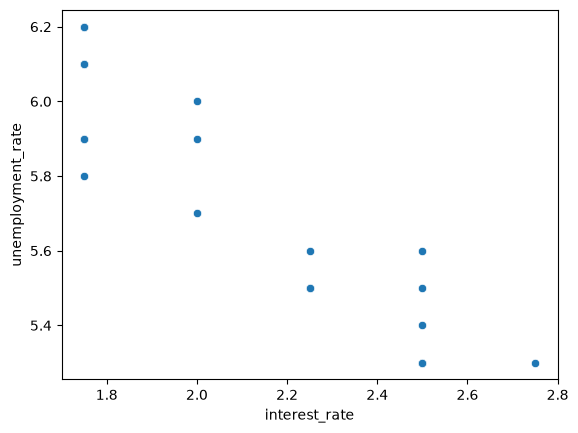

In [13]:
sns.scatterplot(data=df,x='interest_rate',y='unemployment_rate')

### Here we can see that interest_rate and unemployment_rate and inverse correaltion.

In [28]:
### Independent and Dependent features
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [29]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [30]:
y.shape

(24,)

In [31]:
X.shape

(24, 2)

### train test split

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train,X_test,y_train,y_test=train_test_split( X, y, test_size=0.33, random_state=42)

#### Standard Scaling

In [35]:
from sklearn.preprocessing import StandardScaler

In [36]:
scaler = StandardScaler()

In [37]:
X_train = scaler.fit_transform(X_train)

In [39]:
X_train

array([[-0.89073374,  1.25707872],
       [ 1.35954097, -0.62853936],
       [ 1.35954097, -1.5713484 ],
       [-0.14064217,  0.62853936],
       [-0.89073374,  0.94280904],
       [ 1.35954097, -1.5713484 ],
       [ 1.35954097, -1.25707872],
       [-0.89073374,  1.25707872],
       [-0.89073374,  0.94280904],
       [-0.89073374,  0.31426968],
       [-0.89073374,  0.94280904],
       [ 0.6094494 , -0.94280904],
       [-0.14064217, -0.31426968],
       [-0.89073374,  0.        ],
       [-0.89073374,  0.94280904],
       [ 1.35954097, -0.94280904]])

### Now Performing Multiple Linear Regression

In [41]:
from sklearn.linear_model import LinearRegression

In [42]:
linear_reg = LinearRegression()

In [43]:
reg = linear_reg.fit(X_train,y_train)

In [44]:
reg.intercept_,reg.coef_

(np.float64(1037.6875), array([  96.28689501, -101.57024663]))

### Cross validation

In [46]:
# It is the process of validating how well our model will perform for unseen data.

In [47]:
from sklearn.model_selection import cross_val_score

In [49]:
val_score = cross_val_score(linear_reg, X_train,y_train ,scoring="neg_mean_squared_error",cv=5)

In [50]:
val_score

array([-5495.88007512, -7496.90768619, -9203.37178948, -9743.00656351,
        -523.25201601])

In [51]:
np.mean(val_score)

np.float64(-6492.483626060824)

### Prediction

In [53]:
X_test = scaler.transform(X_test)

In [54]:
y_hat = reg.predict(X_test)

In [56]:
y_hat

array([1192.13083729,  824.23971817, 1400.41971162,  856.16016713,
        992.22505325, 1160.21038833,  920.00106505, 1328.19572341])

In [57]:
y_test

8     1159
16     971
0     1464
18     884
11    1075
9     1167
13     965
1     1394
Name: index_price, dtype: int64

In [59]:
# R2 Score
reg.score(X_test,y_test)

0.8640024299625207

### Assumption

<Axes: ylabel='index_price'>

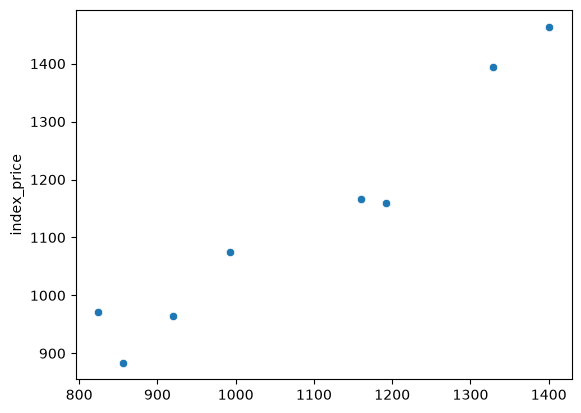

In [61]:
# If our predicted and y_test comes like linerly increasing, then we can se our predition on testing data is good
sns.scatterplot(x=y_hat,y=y_test)

<Axes: xlabel='index_price', ylabel='Density'>

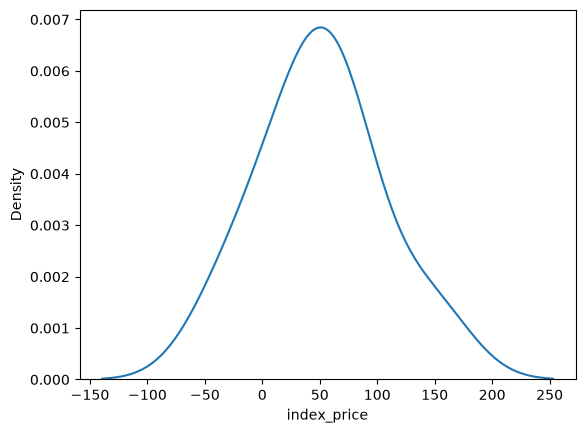

In [63]:
## interpreting with normal distribution of residual
residual = y_test-y_hat
sns.kdeplot(residual)

### Ideally, the residuals should be normally distributed and centered around zero, meaning that most prediction errors are close to zero.